# Thực hành Buổi 10: Time Series Analysis & Forecast với ARIMA

**Khóa đào tạo:** Phân tích Dữ liệu Lớn (Big Data Analysis)

**Công cụ:** Statsmodels (ARIMA/SARIMA), Pandas, Matplotlib

**Đầu vào ➔ Đầu ra:** `market_demand.csv` (3 năm nhu cầu thị trường theo ngày) ➔ mô hình dự báo chuỗi thời gian + biểu đồ forecast + `data/processed/forecast_doanh_thu.csv`

> **Vị trí trong chuỗi bài:** Bài 8 trả lời *"chuyện gì đã xảy ra"* (Descriptive), Bài 9 trả lời *"vì sao"* (Diagnostic). Buổi này bước lên bậc thang thứ ba — **Predictive Analytics**: *"điều gì sẽ xảy ra?"* — dự báo doanh thu tương lai bằng họ mô hình ARIMA. Chạy các cell **theo đúng thứ tự từ trên xuống**.

**Lộ trình 5 bước (quy trình Box–Jenkins rút gọn):**

| Bước | Câu hỏi | Công cụ |
|:---|:---|:---|
| 10.1 | Chuỗi trông thế nào? | vẽ, resample |
| 10.2 | Chuỗi gồm những thành phần gì? | phân rã Trend / Seasonality / Noise |
| 10.3 | Chuỗi có "dừng" không? Cần sai phân mấy lần? | ADF Test, rolling statistics |
| 10.4 | Chọn bậc mô hình (p, q) ra sao? | ACF / PACF |
| 10.5–10.6 | Mô hình dự báo tốt đến đâu? Tương lai ra sao? | ARIMA vs SARIMA, MAE/MAPE, forecast + khoảng tin cậy |

## PHẦN 0 — CHUẨN BỊ VÀ SINH DỮ LIỆU

Cell dưới đây sinh `data/raw/market_demand.csv` — nhu cầu thị trường **theo ngày** trong 3 năm (2023-01-01 ➔ 2025-12-31, 1.096 ngày), với cấu trúc được cấy chủ đích để buổi học "mổ xẻ":

- **Trend**: doanh thu tăng trưởng dần theo thời gian;
- **Seasonality tuần** (chu kỳ 7 ngày): cuối tuần bán mạnh, đầu tuần yếu;
- **Seasonality năm**: cao điểm cuối năm, trũng giữa năm;
- **Noise** + vài cú sốc khuyến mãi (spike) cho giống đời thật.

Hạt giống cố định `seed=42` ➔ mọi máy ra kết quả giống hệt nhau.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True

RAW = Path("../data/raw"); RAW.mkdir(parents=True, exist_ok=True)
PROCESSED = Path("../data/processed"); PROCESSED.mkdir(parents=True, exist_ok=True)

import statsmodels
print("pandas", pd.__version__, "| statsmodels", statsmodels.__version__)

pandas 3.0.5 | statsmodels 0.15.0


In [2]:
# ==== SINH market_demand.csv (chạy 1 lần, kết quả cố định nhờ seed=42) ====
rng = np.random.default_rng(42)
ngay = pd.date_range("2023-01-01", "2025-12-31", freq="D")
t = np.arange(len(ngay))

trend = 480 + 0.16 * t                                     # tăng trưởng dài hạn
hieu_ung_thu = np.array([-38, -30, -16, -6, 20, 58, 44])   # T2..CN: cuối tuần mạnh
mua_tuan = hieu_ung_thu[ngay.dayofweek]
mua_nam = 42 * np.sin(2 * np.pi * (t - 300) / 365.25)      # cao điểm cuối năm
nhieu = rng.normal(0, 18, len(ngay))

doanh_thu = trend + mua_tuan + mua_nam + nhieu             # đơn vị: TRIỆU đồng/ngày
i_khuyen_mai = rng.choice(len(ngay), 8, replace=False)     # 8 cú sốc khuyến mãi
doanh_thu[i_khuyen_mai] += rng.uniform(90, 160, 8)

so_don = (doanh_thu * 1.9 + rng.normal(0, 25, len(ngay))).round().astype(int)

pd.DataFrame({"date": ngay.strftime("%Y-%m-%d"),
              "orders": so_don,
              "revenue_trieu": doanh_thu.round(1)}
             ).to_csv(RAW / "market_demand.csv", index=False)
print(f"Đã sinh market_demand.csv: {len(ngay):,} ngày "
      f"({ngay[0]:%d/%m/%Y} -> {ngay[-1]:%d/%m/%Y})")

Đã sinh market_demand.csv: 1,096 ngày (01/01/2023 -> 31/12/2025)


---
## 10.1. Nạp dữ liệu và nhìn tổng thể

Quy tắc số 1 của chuỗi thời gian trong Pandas: **cột thời gian phải thành `DatetimeIndex`** — mọi công cụ (resample, decompose, ARIMA) đều dựa vào đó.

In [3]:
ts = pd.read_csv(RAW / "market_demand.csv", parse_dates=["date"], index_col="date")
ts = ts.asfreq("D")                    # khai báo tần suất NGÀY — ARIMA cần biết điều này
y = ts["revenue_trieu"]
print(ts.index.freq, "|", len(y), "quan sát, thiếu:", int(y.isna().sum()))
ts.head()

<Day> | 1096 quan sát, thiếu: 0


,orders,revenue_trieu
date,,
2023-01-01,1049,567.3
2023-01-02,871,461.6
2023-01-03,957,502.3
2023-01-04,990,520.1
2023-01-05,938,478.5


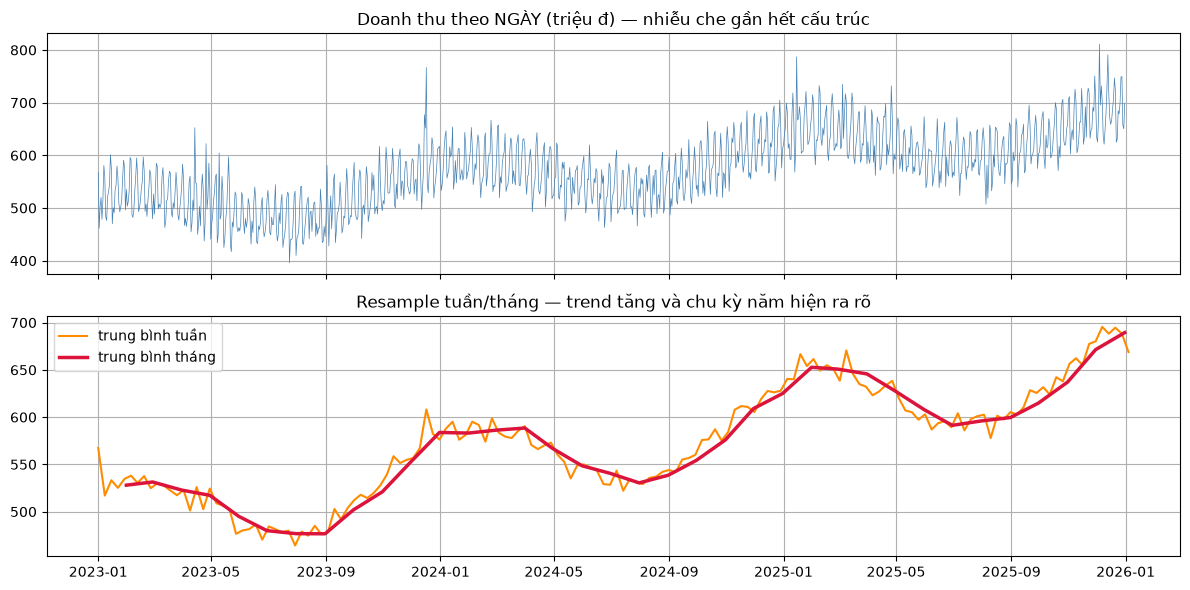

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(y, lw=0.5, color="steelblue")
axes[0].set_title("Doanh thu theo NGÀY (triệu đ) — nhiễu che gần hết cấu trúc")
axes[1].plot(y.resample("W").mean(), color="darkorange", label="trung bình tuần")
axes[1].plot(y.resample("ME").mean(), color="crimson", lw=2.5, label="trung bình tháng")
axes[1].set_title("Resample tuần/tháng — trend tăng và chu kỳ năm hiện ra rõ")
axes[1].legend()
plt.tight_layout(); plt.show()

**Đọc biểu đồ:** nhìn theo ngày chỉ thấy "rừng" nhiễu; resample theo tuần/tháng thì **trend tăng dần** và **sóng chu kỳ năm** hiện ra ngay. Còn chu kỳ tuần? Kiểm tra bằng doanh thu trung bình theo thứ:

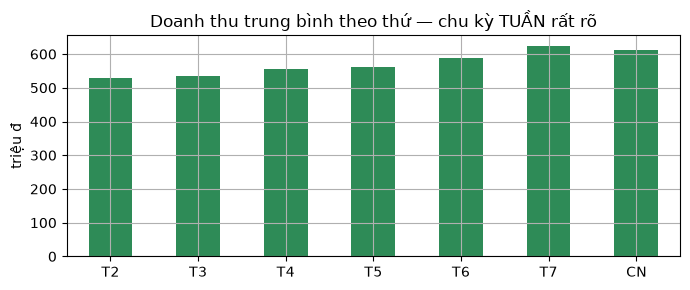

In [5]:
tb_theo_thu = y.groupby(y.index.dayofweek).mean()
tb_theo_thu.index = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
ax = tb_theo_thu.plot(kind="bar", figsize=(7, 3), color="seagreen", rot=0,
                      title="Doanh thu trung bình theo thứ — chu kỳ TUẦN rất rõ")
ax.set_ylabel("triệu đ"); plt.tight_layout(); plt.show()

## 10.2. Phân rã chuỗi thời gian: Trend + Seasonality + Noise

Mô hình cộng (additive): $y_t = T_t + S_t + R_t$ — dùng khi biên độ mùa vụ **ổn định** theo thời gian (như chuỗi này). Nếu biên độ phình to theo mức doanh thu thì dùng mô hình nhân (multiplicative): $y_t = T_t \times S_t \times R_t$.

`seasonal_decompose` tách chuỗi bằng trung bình trượt — đơn giản nhưng đủ để "nhìn thấy" từng thành phần:

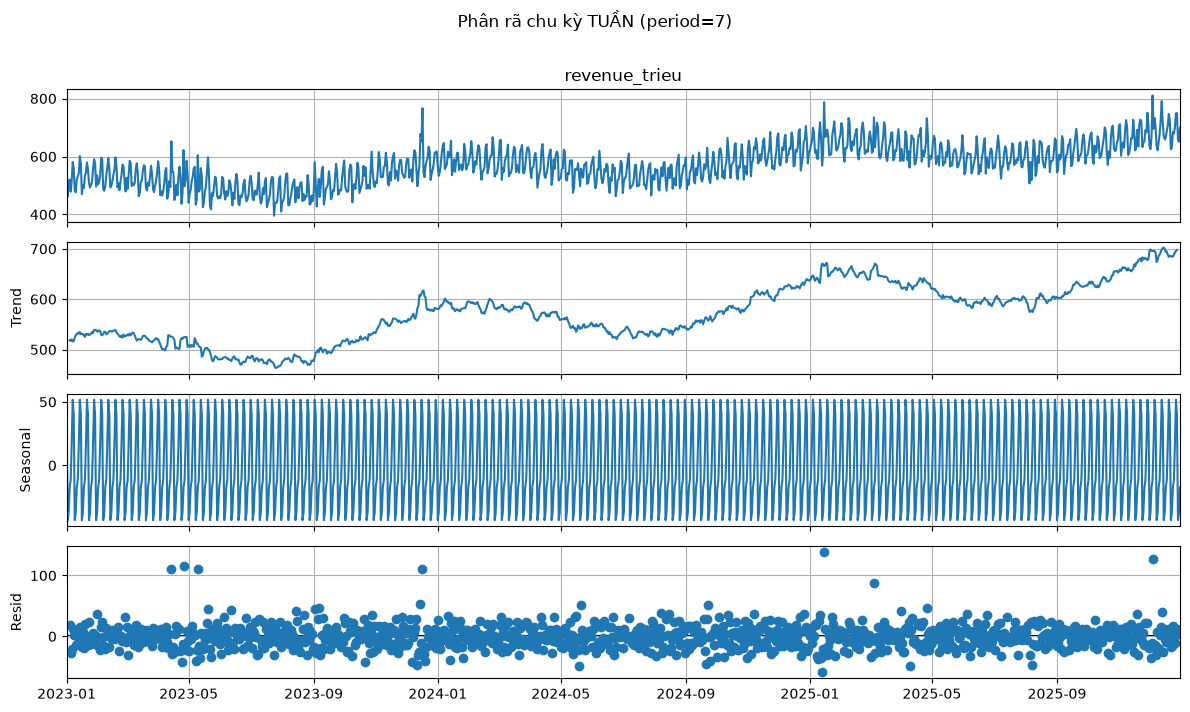

Một chu kỳ mùa vụ (7 ngày, triệu đ):
date
2023-01-01    40.3
2023-01-02   -43.2
2023-01-03   -37.1
2023-01-04   -17.3
2023-01-05   -11.7
2023-01-06    17.3
2023-01-07    51.7
Freq: D


In [6]:
phan_ra = seasonal_decompose(y, model="additive", period=7)
fig = phan_ra.plot()
fig.set_size_inches(12, 7)
fig.suptitle("Phân rã chu kỳ TUẦN (period=7)", y=1.01)
plt.tight_layout(); plt.show()

# Thành phần mùa vụ tuần lặp lại y hệt sau mỗi 7 ngày
print("Một chu kỳ mùa vụ (7 ngày, triệu đ):")
print(phan_ra.seasonal.iloc[:7].round(1).to_string())

In [7]:
# Sức mạnh của từng thành phần (Hyndman): 1 - Var(resid)/Var(resid + thành phần)
manh_trend = max(0, 1 - phan_ra.resid.var() / (phan_ra.resid + phan_ra.trend).var())
manh_mua = max(0, 1 - phan_ra.resid.var() / (phan_ra.resid + phan_ra.seasonal).var())
print(f"Sức mạnh Trend       : {manh_trend:.2f}  (0 = không có, 1 = áp đảo)")
print(f"Sức mạnh Seasonality : {manh_mua:.2f}")
print("==> Cả trend lẫn mùa vụ đều mạnh — mô hình dự báo PHẢI xử lý cả hai.")

Sức mạnh Trend       : 0.90  (0 = không có, 1 = áp đảo)
Sức mạnh Seasonality : 0.77
==> Cả trend lẫn mùa vụ đều mạnh — mô hình dự báo PHẢI xử lý cả hai.


## 10.3. Tính dừng (Stationarity) và kiểm định ADF

ARIMA chỉ làm việc được trên chuỗi **dừng** — trung bình, phương sai không đổi theo thời gian. Chuỗi có trend/mùa vụ là **không dừng**; thuốc chữa là **sai phân** (differencing): $y'_t = y_t - y_{t-1}$ (khử trend, tham số **d**), $y'_t = y_t - y_{t-7}$ (khử mùa vụ tuần, tham số **D**).

**Kiểm định ADF (Augmented Dickey–Fuller):**

| | |
|:---|:---|
| Giả thuyết H₀ | chuỗi KHÔNG dừng (có nghiệm đơn vị) |
| Giả thuyết H₁ | chuỗi dừng |
| Quy tắc | **p-value < 0.05 ➔ bác bỏ H₀ ➔ chuỗi DỪNG** |

In [8]:
ket_qua_adf = []
for ten, chuoi in [("Gốc", y),
                   ("Sai phân bậc 1 (d=1)", y.diff().dropna()),
                   ("Sai phân mùa 7 ngày (D=1)", y.diff(7).dropna()),
                   ("Sai phân 1 + mùa 7", y.diff(7).diff().dropna())]:
    adf, p, *_ = adfuller(chuoi, autolag="AIC")
    ket_qua_adf.append([ten, round(adf, 2), f"{p:.4f}",
                        "DỪNG" if p < 0.05 else "KHÔNG dừng"])
print(pd.DataFrame(ket_qua_adf,
      columns=["Chuỗi", "ADF statistic", "p-value", "Kết luận"]).to_string(index=False))

                    Chuỗi  ADF statistic p-value   Kết luận
                      Gốc           0.20  0.9720 KHÔNG dừng
     Sai phân bậc 1 (d=1)          -8.94  0.0000       DỪNG
Sai phân mùa 7 ngày (D=1)          -7.35  0.0000       DỪNG
       Sai phân 1 + mùa 7         -14.51  0.0000       DỪNG


**Chú ý cách đọc:** chuỗi gốc *có thể* đã cho p-value nhỏ (ADF khá nhạy với mẫu dài), nhưng đồ thị trung bình trượt bên dưới cho thấy **mức trung bình vẫn trôi lên** — với chuỗi có trend rõ như vậy, thực hành chuẩn vẫn là lấy **d=1**. ADF là công cụ hỗ trợ, không thay được con mắt nhìn đồ thị:

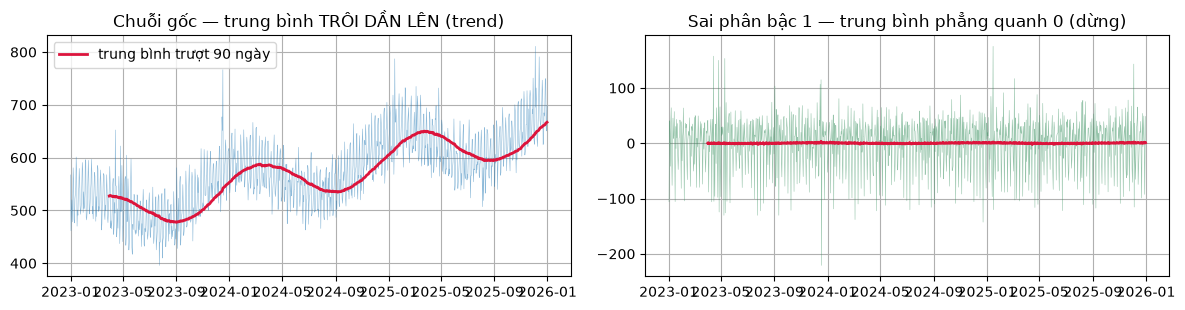

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
axes[0].plot(y, lw=0.4, alpha=0.5)
axes[0].plot(y.rolling(90).mean(), color="crimson", lw=2, label="trung bình trượt 90 ngày")
axes[0].set_title("Chuỗi gốc — trung bình TRÔI DẦN LÊN (trend)")
axes[0].legend()
y_diff = y.diff().dropna()
axes[1].plot(y_diff, lw=0.4, alpha=0.5, color="seagreen")
axes[1].plot(y_diff.rolling(90).mean(), color="crimson", lw=2)
axes[1].set_title("Sai phân bậc 1 — trung bình phẳng quanh 0 (dừng)")
plt.tight_layout(); plt.show()

## 10.4. ACF / PACF — chọn bậc p và q

Trên chuỗi **đã sai phân**, hai biểu đồ tự tương quan gợi ý bậc mô hình:

| Biểu đồ | Đo gì | Gợi ý |
|:---|:---|:---|
| **ACF** (autocorrelation) | tương quan $y_t$ với $y_{t-k}$ | cột tắt dần sau độ trễ q ➔ chọn **MA(q)** |
| **PACF** (partial ACF) | tương quan *trực tiếp* với $y_{t-k}$ (đã loại trung gian) | cột tắt dần sau độ trễ p ➔ chọn **AR(p)** |

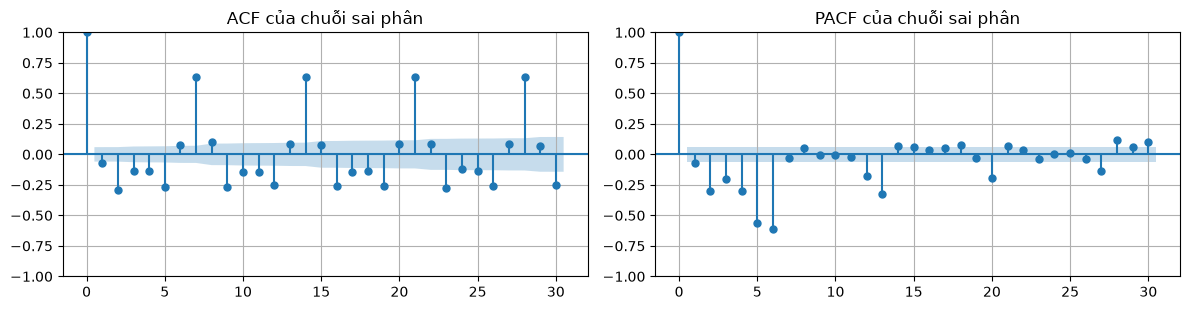

Đọc: các cột VỌT LÊN đều đặn tại lag 7, 14, 21, 28 -> mùa vụ TUẦN còn nguyên
     sau sai phân thường -> cần thành phần MÙA VỤ (SARIMA, m=7).


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
plot_acf(y.diff().dropna(), lags=30, ax=axes[0], title="ACF của chuỗi sai phân")
plot_pacf(y.diff().dropna(), lags=30, ax=axes[1], method="ywm",
          title="PACF của chuỗi sai phân")
plt.tight_layout(); plt.show()
print("Đọc: các cột VỌT LÊN đều đặn tại lag 7, 14, 21, 28 -> mùa vụ TUẦN còn nguyên")
print("     sau sai phân thường -> cần thành phần MÙA VỤ (SARIMA, m=7).")

## 10.5. ARIMA vs SARIMA — huấn luyện và đánh giá trung thực

**ARIMA(p, d, q)** = AR(p) hồi quy trên chính nó + I(d) số lần sai phân + MA(q) hồi quy trên sai số quá khứ. **SARIMA(p,d,q)(P,D,Q)$_m$** thêm bộ tham số y hệt cho chu kỳ mùa vụ m (ở đây m=7).

Nguyên tắc đánh giá **bất di bất dịch**: chia train/test **theo thời gian** — giấu 60 ngày cuối, mô hình chỉ học phần trước đó. Trộn ngẫu nhiên như dữ liệu thường là **gian lận** (mô hình nhìn thấy tương lai).

In [11]:
SO_NGAY_TEST = 60
train, test = y.iloc[:-SO_NGAY_TEST], y.iloc[-SO_NGAY_TEST:]
print(f"Train: {len(train)} ngày ({train.index[0]:%d/%m/%Y} -> {train.index[-1]:%d/%m/%Y})")
print(f"Test : {len(test)} ngày ({test.index[0]:%d/%m/%Y} -> {test.index[-1]:%d/%m/%Y})")

# --- Mô hình 1: ARIMA(1,1,1) — KHÔNG biết mùa vụ ---
mo_hinh_arima = ARIMA(train, order=(1, 1, 1)).fit()

# --- Mô hình 2: SARIMA(1,1,1)(1,1,1)_7 + drift — biết chu kỳ tuần VÀ đà tăng ---
# trend="c" kết hợp d=1 chính là hệ số DRIFT: cho mô hình biết doanh thu
# có đà tăng dài hạn, để dự báo xa không bị "đi ngang".
mo_hinh_sarima = SARIMAX(train, order=(1, 1, 1),
                         seasonal_order=(1, 1, 1, 7), trend="c").fit(disp=False)

print(f"\nAIC  ARIMA(1,1,1)                 : {mo_hinh_arima.aic:,.0f}")
print(f"AIC  SARIMA(1,1,1)(1,1,1)_7 +drift: {mo_hinh_sarima.aic:,.0f}   (AIC thấp hơn = tốt hơn)")

Train: 1036 ngày (01/01/2023 -> 01/11/2025)
Test : 60 ngày (02/11/2025 -> 31/12/2025)



AIC  ARIMA(1,1,1)                 : 10,536
AIC  SARIMA(1,1,1)(1,1,1)_7 +drift: 9,286   (AIC thấp hơn = tốt hơn)


In [12]:
du_bao_arima = mo_hinh_arima.forecast(SO_NGAY_TEST)
du_bao_sarima = mo_hinh_sarima.forecast(SO_NGAY_TEST)

# Baseline "seasonal naive": LẶP LẠI tuần cuối cùng của train suốt 60 ngày.
# CẢNH GIÁC: dùng y.shift(7) trên chuỗi đầy đủ là GIAN LẬN — mỗi ngày test sẽ
# "nhìn trộm" giá trị thật của 7 ngày trước đó, vốn nằm trong chính tập test.
du_bao_naive = pd.Series(np.tile(train.iloc[-7:].values, 9)[:SO_NGAY_TEST],
                         index=test.index)

bang = []
for ten, db in [("Seasonal naive (lặp tuần cuối)", du_bao_naive),
                ("ARIMA(1,1,1)", du_bao_arima),
                ("SARIMA(1,1,1)(1,1,1)_7 +drift", du_bao_sarima)]:
    mae = (test - db.values).abs().mean()
    mape = ((test - db.values).abs() / test).mean() * 100
    bang.append([ten, round(mae, 1), round(mape, 2)])
print(pd.DataFrame(bang, columns=["Mô hình", "MAE (triệu đ)", "MAPE (%)"]).to_string(index=False))
print("\nMột mô hình chỉ ĐÁNG DÙNG khi thắng được baseline ngây thơ.")

                       Mô hình  MAE (triệu đ)  MAPE (%)
Seasonal naive (lặp tuần cuối)           29.7      4.25
                  ARIMA(1,1,1)           46.9      6.61
 SARIMA(1,1,1)(1,1,1)_7 +drift           26.7      3.79

Một mô hình chỉ ĐÁNG DÙNG khi thắng được baseline ngây thơ.


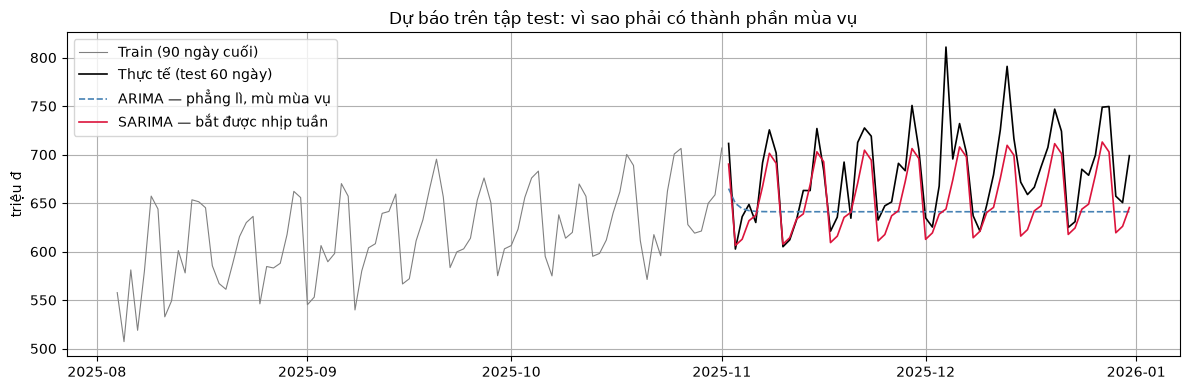

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train.iloc[-90:], lw=0.8, color="gray", label="Train (90 ngày cuối)")
ax.plot(test, lw=1.2, color="black", label="Thực tế (test 60 ngày)")
ax.plot(test.index, du_bao_arima.values, lw=1.2, color="steelblue", ls="--",
        label="ARIMA — phẳng lì, mù mùa vụ")
ax.plot(test.index, du_bao_sarima.values, lw=1.2, color="crimson",
        label="SARIMA — bắt được nhịp tuần")
ax.set_title("Dự báo trên tập test: vì sao phải có thành phần mùa vụ")
ax.set_ylabel("triệu đ"); ax.legend()
plt.tight_layout(); plt.show()

## 10.6. Dự báo tương lai và khoảng tin cậy — deliverable

Mô hình đã qua "kỳ thi" trên tập test. Bước cuối: **huấn luyện lại trên TOÀN BỘ dữ liệu** (không bỏ phí 60 ngày cuối) rồi dự báo **30 ngày chưa hề tồn tại**, kèm khoảng tin cậy 95% — dự báo mà thiếu khoảng tin cậy là dự báo nói dối một nửa.

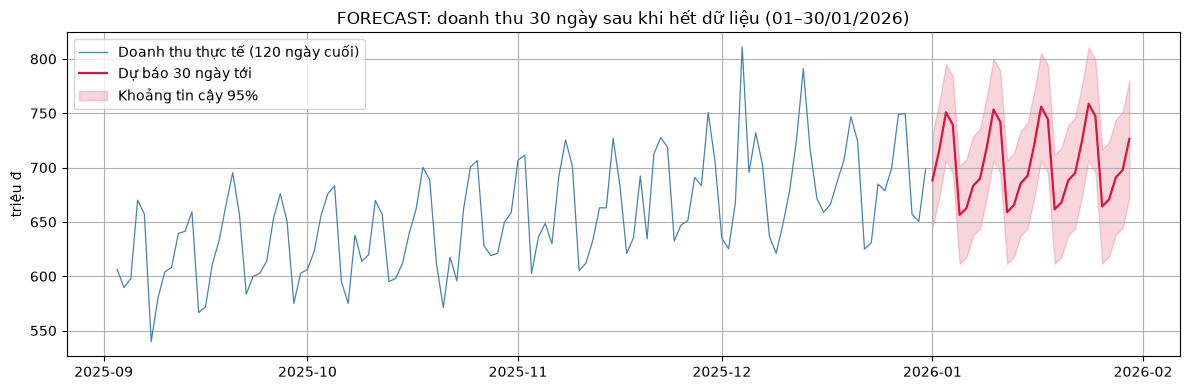

Chú ý: khoảng tin cậy LOE RỘNG DẦN — càng xa hiện tại, càng bất định. Đó là sự trung thực của mô hình.


In [14]:
mo_hinh_cuoi = SARIMAX(y, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                       trend="c").fit(disp=False)
tuong_lai = mo_hinh_cuoi.get_forecast(30)
du_bao = tuong_lai.predicted_mean
khoang_tc = tuong_lai.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y.iloc[-120:], lw=0.9, color="steelblue", label="Doanh thu thực tế (120 ngày cuối)")
ax.plot(du_bao, lw=1.6, color="crimson", label="Dự báo 30 ngày tới")
ax.fill_between(khoang_tc.index, khoang_tc.iloc[:, 0], khoang_tc.iloc[:, 1],
                color="crimson", alpha=0.18, label="Khoảng tin cậy 95%")
ax.set_title("FORECAST: doanh thu 30 ngày sau khi hết dữ liệu (01–30/01/2026)")
ax.set_ylabel("triệu đ"); ax.legend()
plt.tight_layout(); plt.show()

print("Chú ý: khoảng tin cậy LOE RỘNG DẦN — càng xa hiện tại, càng bất định. Đó là sự trung thực của mô hình.")

In [15]:
bao_cao = pd.DataFrame({
    "du_bao_trieu": du_bao.round(1),
    "can_duoi_95": khoang_tc.iloc[:, 0].round(1),
    "can_tren_95": khoang_tc.iloc[:, 1].round(1),
})
bao_cao.index.name = "date"
bao_cao.to_csv(PROCESSED / "forecast_doanh_thu.csv")

print("Đã lưu", PROCESSED / "forecast_doanh_thu.csv")
print(f"\nTổng doanh thu dự báo 30 ngày tới: {du_bao.sum():,.0f} triệu đ")
print(f"(khoảng 95%: {khoang_tc.iloc[:, 0].sum():,.0f} — {khoang_tc.iloc[:, 1].sum():,.0f} triệu đ)")
bao_cao.head(7)

Đã lưu ../data/processed/forecast_doanh_thu.csv

Tổng doanh thu dự báo 30 ngày tới: 21,116 triệu đ
(khoảng 95%: 19,655 — 22,577 triệu đ)


,du_bao_trieu,can_duoi_95,can_tren_95
date,,,
2026-01-01,688.2,645.1,731.2
2026-01-02,715.6,671.8,759.5
2026-01-03,750.8,706.6,795.0
2026-01-04,739.6,695.0,784.1
2026-01-05,656.4,611.5,701.3
2026-01-06,662.6,617.3,707.8
2026-01-07,683.3,637.7,728.9


---
## TỔNG KẾT BUỔI 10

| Bước | Kỹ thuật | Bài học chính |
|:---|:---|:---|
| Nhìn | resample tuần/tháng | nhiễu che cấu trúc — đổi độ phân giải để thấy trend/mùa vụ |
| Phân rã | `seasonal_decompose` | chuỗi = Trend + Seasonality + Noise; đo được sức mạnh từng phần |
| Tính dừng | ADF test + sai phân | p < 0.05 ➔ dừng; trend ➔ d=1, mùa vụ ➔ D=1; ADF không thay được đồ thị |
| Chọn bậc | ACF/PACF | cột vọt tại lag 7, 14, 21 ➔ cần SARIMA m=7 |
| Đánh giá | train/test theo thời gian, MAE/MAPE | phải thắng baseline ngây thơ; không bao giờ trộn ngẫu nhiên |
| Dự báo | refit toàn bộ + `get_forecast` | luôn kèm khoảng tin cậy; càng xa càng bất định |

Bậc thang phân tích đã đi: Descriptive (Bài 8) ➔ Diagnostic (Bài 9) ➔ **Predictive (Bài 10)**. Bậc cuối — Prescriptive (*nên làm gì với dự báo này?*) — thuộc về bài toán tối ưu và quyết định kinh doanh.

---
# BÀI TẬP VỀ NHÀ

Làm trực tiếp vào các cell trống bên dưới. Nộp notebook đã chạy đầy đủ output.

#### Bài tập 1 (Chọn mô hình): Thử 4 cấu hình SARIMA trên tập train: (0,1,1)(0,1,1)₇, (1,1,0)(1,1,0)₇, (1,1,1)(1,1,1)₇, (2,1,2)(1,1,1)₇. Lập bảng AIC và MAPE trên tập test. Cấu hình AIC thấp nhất có phải cấu hình MAPE thấp nhất không? Nhận xét 2–3 câu.

In [16]:
# --- BÀI TẬP 1 ---


#### Bài tập 2 (Dự báo cột khác): Lặp lại quy trình 10.3 ➔ 10.6 cho cột `orders` (số đơn hàng): kiểm định ADF, chọn d/D, huấn luyện SARIMA, đánh giá so với seasonal naive và vẽ biểu đồ forecast 30 ngày kèm khoảng tin cậy.

In [17]:
# --- BÀI TẬP 2 ---


#### Bài tập 3 (Tư duy phản biện): Mô hình của ta được huấn luyện trên dữ liệu có 8 cú sốc khuyến mãi. Nếu tháng tới công ty tung một đợt khuyến mãi lớn chưa từng có, dự báo của SARIMA sẽ sai theo hướng nào, vì sao — và họ mô hình nào (gợi ý: SARIMAX với biến ngoại sinh `exog`) khắc phục được điều đó? Trả lời bằng markdown 4–6 câu.

In [18]:
# --- BÀI TẬP 3 (trả lời bằng markdown hoặc code minh họa) ---
